### 实验04：滞后性测试

#### 实验内容
1. 加载-卸载循环测试
2. 滞后曲线绘制
3. 滞后误差计算
4. 滞后特性分析

#### 输入数据说明
- 文件格式：CSV，三列数据（Time_ms, RawValue, RawGround）
- 文件夹结构：主路径下包含 0, 1, 2, ... 编号子文件夹
- 每个子文件夹包含**两个**CSV文件：
  - 时间戳靠前的文件 → 加载数据
  - 时间戳靠后的文件 → 卸载数据
- 力值由用户在配置中指定

#### 1. 导入库与参数配置

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, glob, re, sys

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
from plot_style import apply_measurement_style, COLORS, add_subplot_label, save_figure, SAVE_DIRS

apply_measurement_style()
SAVE_DIR = SAVE_DIRS[4]

V_REF = 5.0
LSB = V_REF / (2**15)

#### 2. 数据加载函数

In [2]:
def load_sensor_data(file_path):
    """加载传感器CSV数据"""
    df = pd.read_csv(file_path)
    df.columns = ['Time_ms', 'RawValue', 'RawGround']
    return df

def extract_stable_mean(df, start_ratio=0.2, end_ratio=0.8):
    """提取稳定区间的均值"""
    n = len(df)
    start_idx = int(n * start_ratio)
    end_idx = int(n * end_ratio)
    stable_data = df['RawValue'].iloc[start_idx:end_idx]
    return np.mean(stable_data), np.std(stable_data)

def get_csv_files_sorted_by_timestamp(folder_path):
    """获取文件夹内所有CSV文件，按时间戳排序
    文件名格式: Tactile_AD1_R0_C5_YYYYMMDD_HHMMSS.csv
    """
    pattern = os.path.join(folder_path, "*.csv")
    files = glob.glob(pattern)
    
    def extract_timestamp(filepath):
        """从文件名提取时间戳用于排序"""
        basename = os.path.basename(filepath)
        # 尝试匹配 YYYYMMDD_HHMMSS 格式
        match = re.search(r'(\d{8})_(\d{6})', basename)
        if match:
            return match.group(1) + match.group(2)
        return basename  # 如果无法提取，按文件名排序
    
    files.sort(key=extract_timestamp)
    return files

def load_loading_unloading_data(folder_path):
    """从文件夹加载加载和卸载数据
    返回: (loading_mean, loading_std, unloading_mean, unloading_std)
    """
    csv_files = get_csv_files_sorted_by_timestamp(folder_path)
    
    if len(csv_files) < 2:
        print(f"警告: 文件夹 {folder_path} 中CSV文件少于2个")
        return None, None, None, None
    
    # 第一个文件（时间戳较早）= 加载
    # 第二个文件（时间戳较晚）= 卸载
    loading_file = csv_files[0]
    unloading_file = csv_files[1]
    
    df_loading = load_sensor_data(loading_file)
    df_unloading = load_sensor_data(unloading_file)
    
    loading_mean, loading_std = extract_stable_mean(df_loading)
    unloading_mean, unloading_std = extract_stable_mean(df_unloading)
    
    return loading_mean, loading_std, unloading_mean, unloading_std

#### 3. 配置数据路径与力值

In [3]:
_BASE = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "..", "workspace", "test4")
BASE_PATH = _BASE

FORCE_CONFIG = {
    "0":  0.0, "1":  1.0, "2":  2.0, "3":  3.0, "4":  4.0,
    "5":  5.0, "6":  6.0, "7":  7.0, "8":  8.0, "9":  9.0, "10": 10.0,
}

print(f"主路径: {BASE_PATH}")
print(f"配置的测试点数量: {len(FORCE_CONFIG)}")

主路径: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\04_Hysteresis_0.0\..\..\workspace\test4
配置的测试点数量: 11


#### 4. 自动扫描与加载数据

In [4]:
# 自动扫描文件夹并加载数据
loading_forces = []
loading_outputs = []
loading_stds = []
unloading_forces = []
unloading_outputs = []
unloading_stds = []
loaded_folders = []

print("数据加载详情:")
print("="*80)

for folder_name, force_value in sorted(FORCE_CONFIG.items(), key=lambda x: x[1]):
    folder_path = os.path.join(BASE_PATH, folder_name)
    
    if not os.path.isdir(folder_path):
        print(f"✗ 文件夹不存在: {folder_path}")
        continue
    
    csv_files = get_csv_files_sorted_by_timestamp(folder_path)
    
    if len(csv_files) < 2:
        print(f"✗ 文件夹 {folder_name}: CSV文件少于2个 (需要加载+卸载)")
        continue
    
    load_mean, load_std, unload_mean, unload_std = load_loading_unloading_data(folder_path)
    
    if load_mean is None:
        continue
    
    loading_forces.append(force_value)
    loading_outputs.append(load_mean)
    loading_stds.append(load_std)
    
    unloading_forces.append(force_value)
    unloading_outputs.append(unload_mean)
    unloading_stds.append(unload_std)
    
    loaded_folders.append(folder_name)
    
    print(f"✓ 文件夹 {folder_name} ({force_value:.1f} N):")
    print(f"    加载: {os.path.basename(csv_files[0])} → {load_mean:.2f} LSB")
    print(f"    卸载: {os.path.basename(csv_files[1])} → {unload_mean:.2f} LSB")

loading_forces = np.array(loading_forces)
loading_outputs = np.array(loading_outputs)
unloading_forces = np.array(unloading_forces)
unloading_outputs = np.array(unloading_outputs)

print(f"\n共加载 {len(loading_forces)} 个测试点的加载-卸载数据")

数据加载详情:
✓ 文件夹 0 (0.0 N):
    加载: Tactile_AD1_R0_C0_20251222_165325.csv → -4.16 LSB
    卸载: Tactile_AD1_R0_C0_20251222_165343.csv → -4.31 LSB
✓ 文件夹 1 (1.0 N):
    加载: Tactile_AD1_R0_C0_20251222_165518.csv → -1096.98 LSB
    卸载: Tactile_AD1_R0_C0_20251222_165553.csv → -1065.02 LSB
✓ 文件夹 2 (2.0 N):
    加载: Tactile_AD1_R0_C5_20251222_170621.csv → -1962.42 LSB
    卸载: Tactile_AD1_R0_C5_20251222_170717.csv → -1935.82 LSB
✓ 文件夹 3 (3.0 N):
    加载: Tactile_AD1_R0_C5_20251222_170853.csv → -2815.62 LSB
    卸载: Tactile_AD1_R0_C5_20251222_170936.csv → -2812.02 LSB
✓ 文件夹 4 (4.0 N):
    加载: Tactile_AD1_R0_C5_20251222_171036.csv → -3568.24 LSB
    卸载: Tactile_AD1_R0_C5_20251222_171227.csv → -3523.20 LSB
✓ 文件夹 5 (5.0 N):
    加载: Tactile_AD1_R0_C5_20251222_171345.csv → -4277.56 LSB
    卸载: Tactile_AD1_R0_C5_20251222_171434.csv → -4243.45 LSB
✓ 文件夹 6 (6.0 N):
    加载: Tactile_AD1_R0_C5_20251222_171645.csv → -4959.62 LSB
    卸载: Tactile_AD1_R0_C5_20251222_171743.csv → -4940.16 LSB
✓ 文件夹 7 (7.0 N):
    加载: 

#### 5. 显示采集结果

In [5]:
print("\n加载/卸载数据汇总:")
print("-"*70)
print(f"{'文件夹':<8} {'Force(N)':<10} {'加载(LSB)':<15} {'卸载(LSB)':<15} {'差值(LSB)':<12}")
print("-"*70)
for i, folder in enumerate(loaded_folders):
    diff = unloading_outputs[i] - loading_outputs[i]
    print(f"{folder:<8} {loading_forces[i]:<10.1f} {loading_outputs[i]:<15.2f} {unloading_outputs[i]:<15.2f} {diff:<12.2f}")


加载/卸载数据汇总:
----------------------------------------------------------------------
文件夹      Force(N)   加载(LSB)         卸载(LSB)         差值(LSB)     
----------------------------------------------------------------------
0        0.0        -4.16           -4.31           -0.15       
1        1.0        -1096.98        -1065.02        31.95       
2        2.0        -1962.42        -1935.82        26.60       
3        3.0        -2815.62        -2812.02        3.60        
4        4.0        -3568.24        -3523.20        45.04       
5        5.0        -4277.56        -4243.45        34.10       
6        6.0        -4959.62        -4940.16        19.47       
7        7.0        -5556.69        -5533.95        22.74       
8        8.0        -6093.18        -6050.69        42.48       
9        9.0        -6719.50        -6690.47        29.03       
10       10.0       -7500.90        -7513.06        -12.16      


#### 6. 滞后误差计算

In [6]:
# 确保加载和卸载的力值点对应
common_forces = np.intersect1d(loading_forces, unloading_forces)

# 计算满量程跨度
full_scale = np.max(loading_outputs) - np.min(loading_outputs)

# 计算各点滞后误差
hysteresis_errors = []

for force in common_forces:
    load_idx = np.where(loading_forces == force)[0][0]
    unload_idx = np.where(unloading_forces == force)[0][0]
    
    load_output = loading_outputs[load_idx]
    unload_output = unloading_outputs[unload_idx]
    
    error_LSB = unload_output - load_output
    error_FS = abs(error_LSB) / full_scale * 100
    
    hysteresis_errors.append({
        'Force_N': force,
        'Loading_LSB': load_output,
        'Unloading_LSB': unload_output,
        'Error_LSB': error_LSB,
        'Error_percentFS': error_FS
    })

df_hysteresis = pd.DataFrame(hysteresis_errors)

# 最大滞后误差
max_hysteresis = df_hysteresis['Error_percentFS'].max()

print("="*60)
print("【滞后误差分析】")
print("="*60)
print(f"满量程跨度: {full_scale:.2f} LSB")
print()
print(df_hysteresis.to_string(index=False))
print()
print(f"最大滞后误差: {max_hysteresis:.4f} %FS")

【滞后误差分析】
满量程跨度: 7496.74 LSB

 Force_N  Loading_LSB  Unloading_LSB  Error_LSB  Error_percentFS
     0.0    -4.160099      -4.306988  -0.146890         0.001959
     1.0 -1096.977866   -1065.024730  31.953136         0.426227
     2.0 -1962.417695   -1935.817018  26.600677         0.354830
     3.0 -2815.618963   -2812.019674   3.599289         0.048011
     4.0 -3568.237258   -3523.201674  45.035584         0.600735
     5.0 -4277.556941   -4243.454405  34.102536         0.454898
     6.0 -4959.623512   -4940.157202  19.466310         0.259664
     7.0 -5556.692638   -5533.952289  22.740349         0.303336
     8.0 -6093.178982   -6050.694625  42.484357         0.566704
     9.0 -6719.502881   -6690.470588  29.032292         0.387265
    10.0 -7500.904526   -7513.059608 -12.155082         0.162138

最大滞后误差: 0.6007 %FS


#### 7. 滞后曲线可视化

Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test4\png\04_hysteresis_overview.png


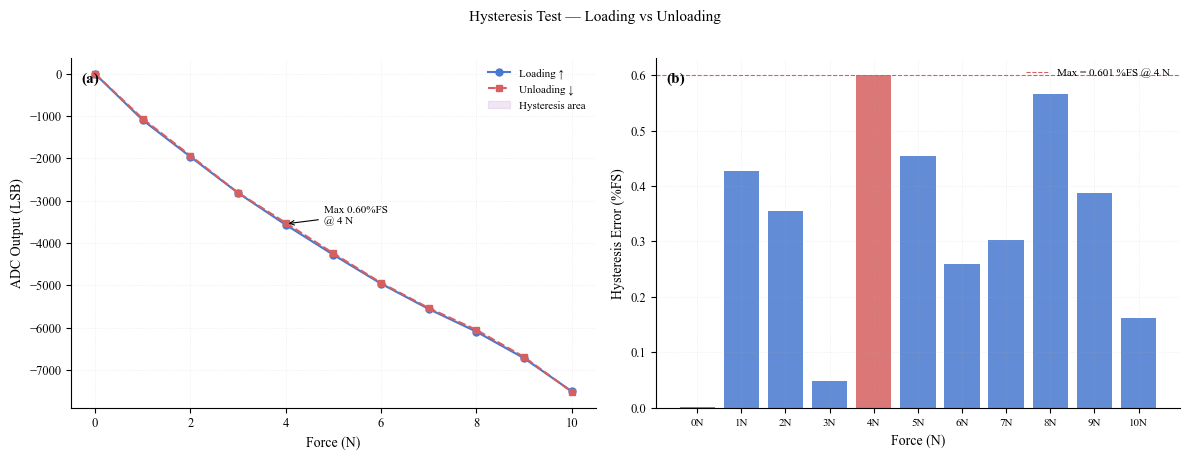

Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test4\png\04a_loop.png
Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test4\png\04b_error_bar.png


In [7]:
# ── Fig 1: 2-panel hysteresis ─────────────────────────────────────────────────
# (a) closed hysteresis loop with fill_between
# (b) per-point hysteresis error %FS bar chart

# Find max hysteresis point for annotation
max_hyst_idx = df_hysteresis['Error_percentFS'].idxmax()
max_hyst_force = df_hysteresis.loc[max_hyst_idx, 'Force_N']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) Hysteresis loop
ax = axes[0]
ax.plot(loading_forces, loading_outputs,
        color=COLORS["loading"], linewidth=1.5, marker="o", markersize=5,
        label="Loading ↑")
ax.plot(unloading_forces, unloading_outputs,
        color=COLORS["unloading"], linewidth=1.5, marker="s", markersize=5,
        linestyle="--", label="Unloading ↓")
ax.fill_between(loading_forces, loading_outputs, unloading_outputs,
                color=COLORS["purple"], alpha=0.18, label="Hysteresis area")
# Annotate max hysteresis point
load_at_max  = loading_outputs[np.where(loading_forces == max_hyst_force)[0][0]]
unload_at_max = unloading_outputs[np.where(unloading_forces == max_hyst_force)[0][0]]
ax.annotate(f"Max {max_hysteresis:.2f}%FS\n@ {max_hyst_force:.0f} N",
            xy=(max_hyst_force, (load_at_max + unload_at_max) / 2),
            xytext=(max_hyst_force + 0.8, (load_at_max + unload_at_max) / 2),
            fontsize=8, arrowprops=dict(arrowstyle="->", lw=0.8))
ax.set_xlabel("Force (N)"); ax.set_ylabel("ADC Output (LSB)")
ax.legend(frameon=False, fontsize=8)
add_subplot_label(ax, "(a)")

# (b) Per-point hysteresis error %FS
ax = axes[1]
bar_c = [COLORS["red"] if f == max_hyst_force else COLORS["blue"]
         for f in df_hysteresis['Force_N']]
ax.bar([f"{f:.0f}N" for f in df_hysteresis['Force_N']],
       df_hysteresis['Error_percentFS'],
       color=bar_c, edgecolor="none", alpha=0.85)
ax.axhline(max_hysteresis, color=COLORS["red"], linewidth=0.8, linestyle="--",
           label=f"Max = {max_hysteresis:.3f} %FS @ {max_hyst_force:.0f} N")
ax.set_xlabel("Force (N)"); ax.set_ylabel("Hysteresis Error (%FS)")
ax.legend(frameon=False, fontsize=8)
ax.tick_params(axis="x", labelsize=8)
add_subplot_label(ax, "(b)")

fig.suptitle("Hysteresis Test — Loading vs Unloading", fontsize=11, y=1.01)
plt.tight_layout()
p = save_figure(fig, SAVE_DIR, "04_hysteresis_overview")
print(f"Saved: {p}")
plt.show()

# ── Individual sub-figures ────────────────────────────────────────────────────
for i, stem in enumerate(["04a_loop", "04b_error_bar"]):
    fig_s, ax_s = plt.subplots(figsize=(6, 4.5))
    if i == 0:
        ax_s.plot(loading_forces, loading_outputs,
                  color=COLORS["loading"], linewidth=1.5, marker="o", markersize=5, label="Loading ↑")
        ax_s.plot(unloading_forces, unloading_outputs,
                  color=COLORS["unloading"], linewidth=1.5, marker="s", markersize=5,
                  linestyle="--", label="Unloading ↓")
        ax_s.fill_between(loading_forces, loading_outputs, unloading_outputs,
                          color=COLORS["purple"], alpha=0.18)
        ax_s.annotate(f"Max {max_hysteresis:.2f}%FS\n@ {max_hyst_force:.0f} N",
                      xy=(max_hyst_force, (load_at_max + unload_at_max) / 2),
                      xytext=(max_hyst_force + 0.8, (load_at_max + unload_at_max) / 2),
                      fontsize=8, arrowprops=dict(arrowstyle="->", lw=0.8))
        ax_s.set_xlabel("Force (N)"); ax_s.set_ylabel("ADC Output (LSB)")
        ax_s.legend(frameon=False, fontsize=8)
    else:
        ax_s.bar([f"{f:.0f}N" for f in df_hysteresis['Force_N']],
                 df_hysteresis['Error_percentFS'], color=bar_c, edgecolor="none", alpha=0.85)
        ax_s.axhline(max_hysteresis, color=COLORS["red"], linewidth=0.8, linestyle="--")
        ax_s.set_xlabel("Force (N)"); ax_s.set_ylabel("Hysteresis Error (%FS)")
        ax_s.tick_params(axis="x", labelsize=8)
    plt.tight_layout()
    p = save_figure(fig_s, SAVE_DIR, stem)
    print(f"Saved: {p}")
    plt.close(fig_s)

#### 8. 加载-卸载对比详细图

Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test4\png\04_loading_unloading_comparison.png


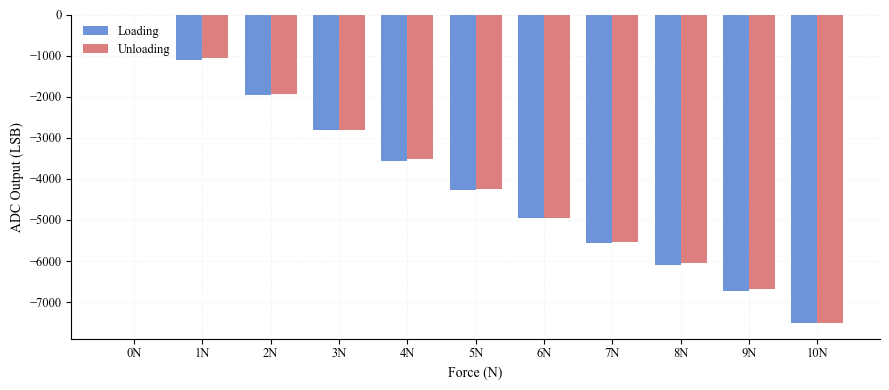

In [8]:
# Loading vs unloading output comparison (grouped bar)
fig_c, ax_c = plt.subplots(figsize=(9, 4))
x = np.arange(len(common_forces))
w = 0.38
ax_c.bar(x - w/2, df_hysteresis['Loading_LSB'],   width=w,
         color=COLORS["loading"],   alpha=0.8, edgecolor="none", label="Loading")
ax_c.bar(x + w/2, df_hysteresis['Unloading_LSB'], width=w,
         color=COLORS["unloading"], alpha=0.8, edgecolor="none", label="Unloading")
ax_c.set_xticks(x)
ax_c.set_xticklabels([f"{f:.0f}N" for f in common_forces])
ax_c.set_xlabel("Force (N)"); ax_c.set_ylabel("ADC Output (LSB)")
ax_c.legend(frameon=False)
plt.tight_layout()
p = save_figure(fig_c, SAVE_DIR, "04_loading_unloading_comparison")
print(f"Saved: {p}")
plt.show()

#### 9. 结果汇总

In [9]:
# 保存结果
df_hysteresis.to_csv('04_hysteresis_data.csv', index=False)

hysteresis_params = {
    'Full_Scale_LSB': full_scale,
    'Max_Hysteresis_percentFS': max_hysteresis,
    'Avg_Hysteresis_percentFS': df_hysteresis['Error_percentFS'].mean(),
    'Num_Test_Points': len(common_forces)
}
pd.DataFrame([hysteresis_params]).to_csv('04_hysteresis_params.csv', index=False)

print("="*60)
print("【实验04 结果汇总】")
print("="*60)
print(f"""
┌─────────────────────────────────────────────────────────┐
│  滞后性测试结果                                         │
├─────────────────────────────────────────────────────────┤
│  测试点数量:       {len(common_forces):>10}                        │
│  满量程跨度:       {full_scale:>10.2f} LSB                    │
│  最大滞后误差:     {max_hysteresis:>10.4f} %FS                  │
│  平均滞后误差:     {df_hysteresis['Error_percentFS'].mean():>10.4f} %FS                  │
├─────────────────────────────────────────────────────────┤
│  评价标准 (参考):                                       │
│    优秀: < 1%FS                                         │
│    良好: 1% ~ 3%FS                                      │
│    一般: 3% ~ 5%FS                                      │
│  文献参考值: 2.4%FS                                     │
└─────────────────────────────────────────────────────────┘
""")

print("滞后数据已保存至: 04_hysteresis_data.csv")
print("滞后参数已保存至: 04_hysteresis_params.csv")

【实验04 结果汇总】

┌─────────────────────────────────────────────────────────┐
│  滞后性测试结果                                         │
├─────────────────────────────────────────────────────────┤
│  测试点数量:               11                        │
│  满量程跨度:          7496.74 LSB                    │
│  最大滞后误差:         0.6007 %FS                  │
│  平均滞后误差:         0.3242 %FS                  │
├─────────────────────────────────────────────────────────┤
│  评价标准 (参考):                                       │
│    优秀: < 1%FS                                         │
│    良好: 1% ~ 3%FS                                      │
│    一般: 3% ~ 5%FS                                      │
│  文献参考值: 2.4%FS                                     │
└─────────────────────────────────────────────────────────┘

滞后数据已保存至: 04_hysteresis_data.csv
滞后参数已保存至: 04_hysteresis_params.csv
